Var(X_t) target: 0.5305374567873501
Mean of v_t (last step): 0.03260374799480034 Expected xi0: 0.0369235


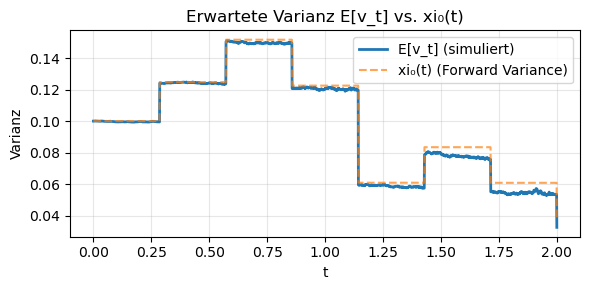

Params: {'eta': 2, 'rho': -0.463451, 'H': 0.440422, 'xi0_knots': array([0.1      , 0.124737 , 0.151619 , 0.1225   , 0.0609106, 0.0834323,
       0.0608478, 0.0369235])}
Example shifted strikes: [0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5]
Example shifted maturities: [0.1 0.3 0.6 0.9 1.2 1.5 1.8 2. ]
IV surface shape: (8, 11)


In [354]:
# Rough Bergomi IV surfaces via rDonsker fBm — Stable IV Extraction + OTM Options
# --------------------------------------------------------------------------------------------------------
# Features:
# - Constant time grid (consistent discretization)
# - Randomized Maturities (±15%)
# - OTM pricing (Calls for K>=S0, Puts for K<S0)
# - Stable implied vol inversion (clipping + NaN handling)
# - Piecewise constant xi0, Antithetic variates, batch seeding
# --------------------------------------------------------------------------------------------------------

import numpy as np
from dataclasses import dataclass
from typing import List, Dict
from scipy.stats import norm

# -------------------------------------------------------------
# Parameter structures
# -------------------------------------------------------------

@dataclass
class RBergomiParams:
    eta: float
    rho: float
    H: float
    xi0_knots: np.ndarray

@dataclass
class SimulationConfig:
    M: int = 20000
    n: int = 1200
    T_max: float = 2.0
    S0: float = 1.0
    strikes: np.ndarray = None
    maturities: np.ndarray = None
    batch_size: int = 5000
    G: int = 10

    def __post_init__(self):
        if self.strikes is None:
            self.strikes = np.array([0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5])
        if self.maturities is None:
            self.maturities = np.array([0.1,0.3,0.6,0.9,1.2,1.5,1.8,2.0])

# -------------------------------------------------------------
# rDonsker fractional Brownian motion simulator
# -------------------------------------------------------------

def fBm_path_rDonsker(grid_points: int, M: int, H: float, T: float) -> np.ndarray:
    """
    rDonsker fractional Brownian motion paths with correct variance scaling.
    Ensures Var[X_t] ≈ t^{2H}.
    """
    dt = T / (grid_points - 1)
    dw = np.random.normal(0.0, np.sqrt(dt), size=(M, grid_points - 1))
    i = np.arange(1, grid_points)
    # "Optimal" Donsker kernel (from Bayer, Friz, Gatheral 2016)
    opt_k = ((i**(2*H) - (i-1)**(2*H)) / (2*H)) ** 0.5

    Y = np.zeros((M, grid_points))
    for m in range(M):
        conv = np.convolve(opt_k, dw[m, :])[:grid_points - 1]
        Y[m, 1:] = conv

    # empirically normalize to Var[X_T] = T^{2H}
    scale = T**H / np.std(Y[:, -1])
    Y *= scale
    return Y

# -------------------------------------------------------------
# Piecewise constant forward variance curve
# -------------------------------------------------------------

def build_xi0_piecewise_constant(knots: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    T_max = t_grid[-1]
    knot_times = np.linspace(0.0, T_max, len(knots))
    idx = np.digitize(t_grid, knot_times) - 1
    idx = np.clip(idx, 0, len(knots) - 1)
    return knots[idx]

# -------------------------------------------------------------
# Price simulation with correlated Brownian motions
# -------------------------------------------------------------

def simulate_price_paths(S0: float, t: np.ndarray, X: np.ndarray, dw: np.ndarray, dW_perp: np.ndarray,
                         xi0_t: np.ndarray, eta: float, rho: float, H: float) -> np.ndarray:
    n = min(X.shape[1], t.shape[0], dw.shape[1] + 1, xi0_t.shape[0])
    X, t, xi0_t = X[:, :n], t[:n], xi0_t[:n]
    dw, dW_perp = dw[:, :n-1], dW_perp[:, :n-1]
    M = X.shape[0]
    dt = np.mean(np.diff(t))
    t2H = np.power(t, 2.0*H)
    exp_term = np.clip(eta * X - 0.5 * eta**2 * t2H, -10, 10)
    v = xi0_t * np.exp(exp_term)
    dW_S = rho * dw + np.sqrt(max(1.0 - rho*rho, 0.0)) * dW_perp
    logS = np.zeros((M, n))
    logS[:, 0] = np.log(S0)
    logS[:, 1:] = logS[:, [0]] + np.cumsum(-0.5*v[:, :-1]*dt + np.sqrt(np.maximum(v[:, :-1], 0.0))*dW_S, axis=1)
    return np.exp(logS)

# -------------------------------------------------------------
# Plain OTM pricing (no control variate)
# -------------------------------------------------------------

def price_calls_plain(ST: np.ndarray, S0: float, Ks: np.ndarray) -> np.ndarray:
    return np.mean(np.maximum(ST[:, None] - Ks[None, :], 0.0), axis=0)

def price_puts_plain(ST: np.ndarray, S0: float, Ks: np.ndarray) -> np.ndarray:
    return np.mean(np.maximum(Ks[None, :] - ST[:, None], 0.0), axis=0)

def price_otm_plain(ST: np.ndarray, S0: float, Ks: np.ndarray) -> np.ndarray:
    calls = price_calls_plain(ST, S0, Ks)
    puts = price_puts_plain(ST, S0, Ks)
    return np.where(Ks >= S0, calls, puts)

# -------------------------------------------------------------
# Black–Scholes pricing + implied vol inversion (robust)
# -------------------------------------------------------------

def bs_call_price(S0, K, T, vol):
    if vol <= 0.0 or T <= 0.0:
        return max(S0 - K, 0.0)
    sT = np.sqrt(T)
    d1 = (np.log(S0 / K) + 0.5 * vol**2 * T) / (vol * sT)
    d2 = d1 - vol * sT
    return S0 * norm.cdf(d1) - K * norm.cdf(d2)

def bs_put_price(S0, K, T, vol):
    if vol <= 0.0 or T <= 0.0:
        return max(K - S0, 0.0)
    sT = np.sqrt(T)
    d1 = (np.log(S0 / K) + 0.5 * vol**2 * T) / (vol * sT)
    d2 = d1 - vol * sT
    return K * norm.cdf(-d2) - S0 * norm.cdf(-d1)

def implied_vol_from_price_otm(S0, K, T, price, tol=1e-7):
    if price < 1e-8:
        return np.nan
    price_func = bs_call_price if K >= S0 else bs_put_price
    a, b = 1e-8, 5.0
    fa = price_func(S0, K, T, a) - price
    fb = price_func(S0, K, T, b) - price
    if fa * fb > 0:
        return np.nan
    for _ in range(80):
        m = 0.5 * (a + b)
        fm = price_func(S0, K, T, m) - price
        if np.sign(fm) == np.sign(fa):
            a, fa = m, fm
        else:
            b, fb = m, fm
        if abs(b - a) < tol:
            break
    vol = max(0.0, 0.5 * (a + b))
    return np.clip(vol, 0.01, 3.0)

def surface_implied_vols_otm(S0, Ks, T, prices):
    ivs = [implied_vol_from_price_otm(S0, float(K), float(T), float(p)) for K, p in zip(Ks, prices)]
    return np.nan_to_num(np.array(ivs), nan=0.05)

# -------------------------------------------------------------
# Parameter sampling
# -------------------------------------------------------------

def sample_param_set() -> RBergomiParams:
    xi0_knots = np.array([0.1,  0.124737 ,  0.151619 ,  0.1225   ,  0.0609106,
        0.0834323,  0.0608478,  0.0369235])
    eta = 2
    rho = -0.463451
    H = 0.440422
    return RBergomiParams(eta=eta, rho=rho, H=H, xi0_knots=xi0_knots)

# -------------------------------------------------------------
# Main workflow
# -------------------------------------------------------------

def generate_surfaces(num_sets=1, forward_curves_per_set=1, cfg=SimulationConfig(), seed=42) -> List[Dict]:
    np.random.seed(seed)
    results = []
    n, T_max = cfg.n, cfg.T_max
    base_t = np.linspace(0.0, T_max, n)
    dt = base_t[1] - base_t[0]

    for s in range(num_sets):
        params = sample_param_set()
        np.random.seed(seed + s)

        M_half = cfg.M // 2
        dw_half = np.random.normal(0.0, np.sqrt(dt), size=(M_half, n - 1))
        dW_perp_half = np.random.normal(0.0, np.sqrt(dt), size=(M_half, n - 1))
        dw = np.vstack([dw_half, -dw_half])
        dW_perp = np.vstack([dW_perp_half, -dW_perp_half])

        X = fBm_path_rDonsker(n, cfg.M, params.H, T_max)
        grids = [base_t.copy()] * cfg.G

        for j in range(forward_curves_per_set):
            knots = params.xi0_knots
            for g_id, t in enumerate(grids):
                T_shift = 0#np.random.uniform(-0.15, 0.15)
                maturities_shifted = np.clip(cfg.maturities + T_shift, 0.05, T_max)
                strikes_shifted = np.clip(cfg.strikes, 0.5, 1.5)

                xi0_t = build_xi0_piecewise_constant(knots, t)
                S = simulate_price_paths(cfg.S0, t, X, dw, dW_perp, xi0_t, params.eta, params.rho, params.H)
                t2H = np.power(t, 2.0 * params.H)
                v_t = xi0_t * np.exp(params.eta * X - 0.5 * params.eta**2 * t2H)
                avg_v = np.mean(v_t, axis=0)
                print("Var(X_t) target:", np.mean(np.var(X, axis=0)) / np.power(T_max, 2*params.H))
                print("Mean of v_t (last step):", np.mean(v_t[:, -1]), "Expected xi0:", xi0_t[-1])
                import matplotlib.pyplot as plt
                plt.figure(figsize=(6, 3))
                plt.plot(t, avg_v, label="E[v_t] (simuliert)", lw=2)
                plt.plot(t, xi0_t, "--", label="xi₀(t) (Forward Variance)", alpha=0.7)
                plt.xlabel("t")
                plt.ylabel("Varianz")
                plt.title("Erwartete Varianz E[v_t] vs. xi₀(t)")
                plt.legend()
                plt.grid(alpha=0.3)
                plt.tight_layout()
                plt.show()

                mat_idx = [np.argmin(np.abs(t - Tm)) for Tm in maturities_shifted]
                price_surf = np.zeros((len(maturities_shifted), len(strikes_shifted)))
                iv_surf = np.zeros_like(price_surf)

                for mi, idx in enumerate(mat_idx):
                    ST = S[:, idx]
                    prices = price_otm_plain(ST, cfg.S0, strikes_shifted)
                    price_surf[mi, :] = prices
                    iv_surf[mi, :] = surface_implied_vols_otm(cfg.S0, strikes_shifted, t[idx], prices)

                results.append({
                    "set_id": s,
                    "fwd_id": j,
                    "grid_id": g_id,
                    "params": vars(params),
                    "grid": {
                        "strikes": strikes_shifted.astype(float),
                        "maturities": maturities_shifted.astype(float),
                    },
                    "price_surface": price_surf,
                    "iv_surface": iv_surf,
                })
    return results

# -------------------------------------------------------------
# Example run
# -------------------------------------------------------------

if __name__ == "__main__":
    cfg = SimulationConfig(M=120000, n=2000, T_max=2.0, S0=1.0, G=1)
    surfaces = generate_surfaces(num_sets=1, forward_curves_per_set=1, cfg=cfg)
    R0 = surfaces[0]
    print("Params:", R0["params"])
    print("Example shifted strikes:", R0["grid"]["strikes"])
    print("Example shifted maturities:", R0["grid"]["maturities"])
    print("IV surface shape:", R0["iv_surface"].shape)


In [355]:
surfaces[0]["iv_surface"]

array([[0.05      , 0.37025404, 0.37229304, 0.33770842, 0.31586853,
        0.30824681, 0.31448876, 0.32801394, 0.3443562 , 0.36074747,
        0.37730549],
       [0.44911717, 0.39697793, 0.35499153, 0.32457386, 0.30474638,
        0.29960697, 0.30458828, 0.31804499, 0.33522454, 0.35265421,
        0.3701475 ],
       [0.4379901 , 0.39074023, 0.35309603, 0.32410522, 0.30533229,
        0.2984601 , 0.30343694, 0.31520431, 0.32998984, 0.34606953,
        0.36242296],
       [0.42729427, 0.38295788, 0.34689133, 0.31955552, 0.30235586,
        0.29438411, 0.29916217, 0.31037045, 0.32426146, 0.33931923,
        0.3543858 ],
       [0.40212129, 0.36089999, 0.32780749, 0.30250859, 0.28651995,
        0.27607967, 0.28027241, 0.2902991 , 0.30285207, 0.31640952,
        0.33008982],
       [0.3725413 , 0.33470486, 0.30416233, 0.28102552, 0.26659292,
        0.25588852, 0.25981163, 0.2689184 , 0.28049816, 0.29291322,
        0.30530606],
       [0.35257426, 0.31678383, 0.28805521, 0.26624736, 0.

In [356]:
surfaces[0]["price_surface"]

array([[0.00000000e+00, 1.22580902e-07, 3.39388091e-05, 6.36344745e-04,
        7.10459080e-03, 3.88816967e-02, 9.40048613e-03, 1.80358711e-03,
        3.28668299e-04, 6.16780793e-05, 1.27732307e-05],
       [1.24224324e-04, 5.31655416e-04, 2.12398850e-03, 7.94262395e-03,
        2.53439308e-02, 6.54099562e-02, 3.08721830e-02, 1.45122928e-02,
        7.18629393e-03, 3.76235848e-03, 2.10341216e-03],
       [1.79586915e-03, 4.38492774e-03, 1.02712943e-02, 2.29210876e-02,
        4.81266485e-02, 9.20478778e-02, 5.61758054e-02, 3.51485527e-02,
        2.29805034e-02, 1.57889589e-02, 1.13582658e-02],
       [5.04458693e-03, 1.00742413e-02, 1.93494701e-02, 3.62113413e-02,
        6.55343366e-02, 1.11082078e-01, 7.50837999e-02, 5.24421205e-02,
        3.81241794e-02, 2.88723541e-02, 2.26198836e-02],
       [7.56168240e-03, 1.39797060e-02, 2.50848937e-02, 4.39382307e-02,
        7.50001491e-02, 1.20174042e-01, 8.41550778e-02, 6.09189591e-02,
        4.58191900e-02, 3.57587469e-02, 2.88022490e-